# Predicting Bird Geolocation Region from Latitude and Longitude

This notebook maps bird geolocations (latitude and longitude) to North American regions: US states, Canadian provinces, and other North American countries. It trains a classifier to predict the region and visualizes the results using folium.

## 1. Import Required Libraries
We use pandas, scikit-learn, folium, and geopandas for geospatial mapping and region assignment across North America.

In [1]:
import pandas as pd
import numpy as np
import folium
import geopandas as gpd
import os
from birds.settings import load_settings
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.utils import class_weight
from sklearn.utils.multiclass import unique_labels
import matplotlib.pyplot as plt
from collections import Counter

## 2. Load and Inspect Data
Load the NABBP dataset including 'lat_dd' and 'lon_dd'. Birds may be located anywhere in North America (US, Canada, Mexico, Caribbean, Central America).

In [2]:
settings = load_settings()
DATA_PATH = os.path.join(settings.nabbp_data_path, "NABBP_2025_grp_01.csv.gz")
df = pd.read_csv(DATA_PATH, compression='gzip', low_memory=True, engine='pyarrow')
df.head()

,band,original_band,other_bands,event_type,event_date,event_day,event_month,event_year,iso_country,iso_subdivision,...,sex_code,permit,band_status_code,how_obtained_code,who_obtained_code,reporting_method,present_condition,min_age_at_enc,record_source,record_id
0,B88685577705,B88685577705,None,E,09/05/1996,5,9,1996,CA,CA-AB,...,NaN,None,None,1.0,21.0,6.0,5.0,6.25,E,-12887255
1,B68685512971,B68685512971,None,E,09/25/1992,25,9,1992,CA,CA-AB,...,NaN,None,None,1.0,22.0,1.0,5.0,1.25,E,-13054259
2,B68685568815,B68685568815,None,E,09/16/1992,16,9,1992,CA,CA-AB,...,NaN,None,None,1.0,21.0,1.0,3.0,1.25,E,-13057315
3,B24925755707,B24925755707,None,E,09/22/1992,22,9,1992,CA,CA-AB,...,NaN,None,None,1.0,21.0,1.0,3.0,1.25,E,-13056448
4,B94925781537,B94925781537,None,E,09/08/1992,8,9,1992,CA,CA-AB,...,NaN,None,None,1.0,21.0,1.0,3.0,4.25,E,-13052122


In [6]:
# Add a 'season' column based on 'event_month' (1=Jan, ..., 12=Dec)
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'fall'
    else:
        return 'unknown'

df['event_month'] = pd.to_numeric(df['event_month'], errors='coerce')
df = df.dropna(subset=['event_month'])
df['event_month'] = df['event_month'].astype(int)
df['season'] = df['event_month'].apply(month_to_season)

## Visualize Raw Geolocations with a Folium Map
Before preprocessing, let's visualize a sample of bird datapoints from the entire North American region on a map using folium.

In [7]:
# Plot a random sample of 5000 raw datapoints on a folium map and save to HTML
n_points = 5000
sample_df = df.sample(n=n_points, random_state=42) if len(df) > n_points else df
raw_map = folium.Map(location=[40, -100], zoom_start=3)  # Center of North America
for _, row in sample_df.iterrows():
    if pd.notnull(row['lat_dd']) and pd.notnull(row['lon_dd']):
        folium.CircleMarker(
            location=[row['lat_dd'], row['lon_dd']],
            radius=2,
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.5
        ).add_to(raw_map)
raw_map.save('north_america_raw_geolocations_map.html')
print('Map saved to north_america_raw_geolocations_map.html')

Map saved to north_america_raw_geolocations_map.html


## 3. Preprocess Geolocation Data
Filter out rows with missing or invalid latitude/longitude values and handle outliers. Use North American bounds for filtering.

In [8]:
# Filter for valid North American latitude and longitude, and remove null island (lat=0, lon=0)
na_lat_bounds = (7, 84)
na_lon_bounds = (-168, -52)
df = df.dropna(subset=['lat_dd', 'lon_dd'])
df = df[(df['lat_dd'] >= na_lat_bounds[0]) & (df['lat_dd'] <= na_lat_bounds[1])]
df = df[(df['lon_dd'] >= na_lon_bounds[0]) & (df['lon_dd'] <= na_lon_bounds[1])]
df = df[~((df['lat_dd'] == 0) & (df['lon_dd'] == 0))]
df[['lat_dd', 'lon_dd']].describe()

,lat_dd,lon_dd
count,1.812955e+06,1.812955e+06
mean,5.761840e+01,-9.910074e+01
std,1.313036e+01,2.069682e+01
min,8.416670e+00,-1.667765e+02
25%,5.150000e+01,-1.005000e+02
50%,6.050000e+01,-9.450000e+01
75%,6.750000e+01,-8.650000e+01
max,8.187439e+01,-5.425000e+01


## 4. Map Coordinates to North American Regions
Assign each (lat_dd, lon_dd) to a US state, Canadian province, or other North American country using a shapefile and geopandas.

In [9]:
north_america = {
    # Northern mainland countries
    "Canada": {"type": "country", "iso": "CAN"},
    "United States": {"type": "country", "iso": "USA"},
    "Mexico": {"type": "country", "iso": "MEX"},
    # Central America countries
    "Belize": {"type": "country", "iso": "BLZ"},
    "Costa Rica": {"type": "country", "iso": "CRI"},
    "El Salvador": {"type": "country", "iso": "SLV"},
    "Guatemala": {"type": "country", "iso": "GTM"},
    "Honduras": {"type": "country", "iso": "HND"},
    "Nicaragua": {"type": "country", "iso": "NIC"},
    "Panama": {"type": "country", "iso": "PAN"},
    # Caribbean countries
    "Antigua and Barbuda": {"type": "country", "iso": "ATG"},
    "Bahamas": {"type": "country", "iso": "BHS"},
    "Barbados": {"type": "country", "iso": "BRB"},
    "Cuba": {"type": "country", "iso": "CUB"},
    "Dominica": {"type": "country", "iso": "DMA"},
    "Dominican Republic": {"type": "country", "iso": "DOM"},
    "Grenada": {"type": "country", "iso": "GRD"},
    "Haiti": {"type": "country", "iso": "HTI"},
    "Jamaica": {"type": "country", "iso": "JAM"},
    "Saint Kitts and Nevis": {"type": "country", "iso": "KNA"},
    "Saint Lucia": {"type": "country", "iso": "LCA"},
    "Saint Vincent and the Grenadines": {"type": "country", "iso": "VCT"},
    "Trinidad and Tobago": {"type": "country", "iso": "TTO"},
    # Territories
    "Puerto Rico": {"type": "territory", "iso": "PRI"},
    "Greenland": {"type": "territory", "iso": "GRL"},
    "Bermuda": {"type": "territory", "iso": "BMU"},
    "Guadeloupe": {"type": "territory", "iso": "GLP"},
    "Martinique": {"type": "territory", "iso": "MTQ"},
    "Aruba": {"type": "territory", "iso": "ABW"},
    "Curaçao": {"type": "territory", "iso": "CUW"},
    "Sint Maarten": {"type": "territory", "iso": "SXM"},
    "Saint Martin": {"type": "territory", "iso": "MAF"},
    "Saint Barthélemy": {"type": "territory", "iso": "BLM"},
    "British Virgin Islands": {"type": "territory", "iso": "VGB"},
    "U.S. Virgin Islands": {"type": "territory", "iso": "VIR"},
    "Turks and Caicos Islands": {"type": "territory", "iso": "TCA"},
    "Cayman Islands": {"type": "territory", "iso": "CYM"},
    "Montserrat": {"type": "territory", "iso": "MSR"},
    "Anguilla": {"type": "territory", "iso": "AIA"},
    "Saint Pierre and Miquelon": {"type": "territory", "iso": "SPM"},
    "Bonaire, Sint Eustatius and Saba": {"type": "territory", "iso": "BES"},
    # Minor/disputed/uninhabited
    "Navassa Island": {"type": "territory", "iso": None},
    "Clipperton Island": {"type": "territory", "iso": None},
}

In [10]:
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [11]:
# Assign country to each row in df based on lat_dd/lon_dd and world geometry
points_gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['lon_dd'], df['lat_dd']), crs=world.crs)
country_name = "ADMIN"
joined = gpd.sjoin(points_gdf, world[['geometry', country_name]], how='left', predicate='within')
df['country_from_geom'] = joined[country_name].values
df['country_from_geom'].value_counts()

country_from_geom
Canada                      1111566
United States of America     408919
Mexico                         2975
Costa Rica                      371
Trinidad and Tobago             349
Cuba                             35
Panama                            5
Greenland                         2
Guatemala                         1
Name: count, dtype: int64

In [ ]:
list(set(df['country_from_geom']))

['Guatemala',
 'Costa Rica',
 'Panama',
 'Mexico',
 nan,
 'United States of America',
 'Cuba',
 'Greenland',
 'Trinidad and Tobago',
 'Canada']

Feature importances for geolocation prediction:
             feature  importance
1        event_month    0.343191
8             season    0.190219
4           age_code    0.189330
3    extra_info_code    0.146629
7     min_age_at_enc    0.037424
2        bird_status    0.036150
5           sex_code    0.029097
6  present_condition    0.017311
0         event_type    0.010649


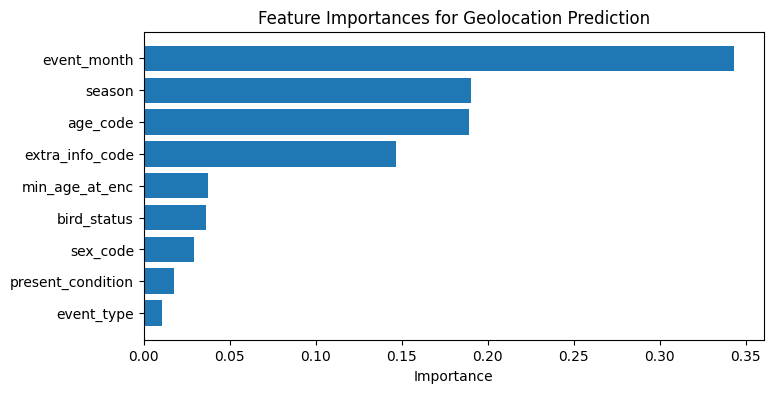

In [13]:
# --- Feature Selection: Evaluate feature importance for geolocation prediction ---
from sklearn.preprocessing import LabelEncoder

# Prepare data for feature selection
feature_cols = ['event_type',
       'event_month', 'bird_status',
       'extra_info_code', 'age_code', 'sex_code',
       'present_condition', 'min_age_at_enc',
       'season']

# Only use numeric columns or encode categoricals
available_cols = [col for col in feature_cols if col in df.columns]
X_fs = df[available_cols].copy()

# Encode all object/categorical columns
for col in X_fs.select_dtypes(include=['object', 'category']).columns:
    X_fs[col] = LabelEncoder().fit_transform(X_fs[col].astype(str))

# Encode categorical target
le = LabelEncoder()
y_fs = le.fit_transform(df['country_from_geom'].astype(str))

# Fit a random forest for feature importance
rf_fs = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fs.fit(X_fs, y_fs)
importances = rf_fs.feature_importances_

# Show feature importances
feature_importance_df = pd.DataFrame({'feature': X_fs.columns, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)
print('Feature importances for geolocation prediction:')
print(feature_importance_df)

# Plot feature importances
plt.figure(figsize=(8,4))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importances for Geolocation Prediction')
plt.gca().invert_yaxis()
plt.show()

In [14]:
# Use the most important features for prediction (from feature selection)
# Features: lat_dd, lon_dd, event_month, season, age_code, extra_info_code
selected_features = ['event_month', 'season', 'age_code', 'extra_info_code']
# Only keep features that exist in df
selected_features = [f for f in selected_features if f in df.columns]
X = df[selected_features].copy()
# One-hot encode 'season' if present
if 'season' in X.columns:
    X = pd.get_dummies(X, columns=['season'])
# Fill missing values for numeric columns
for col in X.select_dtypes(include=[np.number]).columns:
    X[col] = X[col].fillna(X[col].median())
# Encode categorical columns (except one-hot)
from sklearn.preprocessing import LabelEncoder
for col in X.select_dtypes(include=['object', 'category']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))
y = df['country_from_geom']
# To address class imbalance, use stratified sampling and class_weight in the classifier

# Remove rows with NaN in y
mask = ~y.isna()
X = X[mask]
y = y[mask]

# Remove classes with <2 samples (required for stratified split)
value_counts = y.value_counts()
valid_classes = value_counts[value_counts >= 2].index
X = X[y.isin(valid_classes)]
y = y[y.isin(valid_classes)]

# Stratified split to preserve rare classes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Compute class weights to help model learn rare classes
classes = np.unique(y_train)
weights = class_weight.compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weight_dict)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [15]:
print('Unique classes in y_train:', np.unique(y_train))
print('Unique classes in y_test:', np.unique(y_test))
print('Unique classes in y_pred:', np.unique(y_pred))

Unique classes in y_train: ['Canada' 'Costa Rica' 'Cuba' 'Greenland' 'Mexico' 'Panama'
 'Trinidad and Tobago' 'United States of America']
Unique classes in y_test: ['Canada' 'Costa Rica' 'Cuba' 'Mexico' 'Panama' 'Trinidad and Tobago'
 'United States of America']
Unique classes in y_pred: ['Canada' 'Costa Rica' 'Cuba' 'Greenland' 'Mexico' 'Panama'
 'Trinidad and Tobago' 'United States of America']


## 5. Train a Classification Model to Predict Region
Train a RandomForest classifier to predict the region (US state, Canadian province, or other North American country) from latitude and longitude.

Accuracy: 0.74


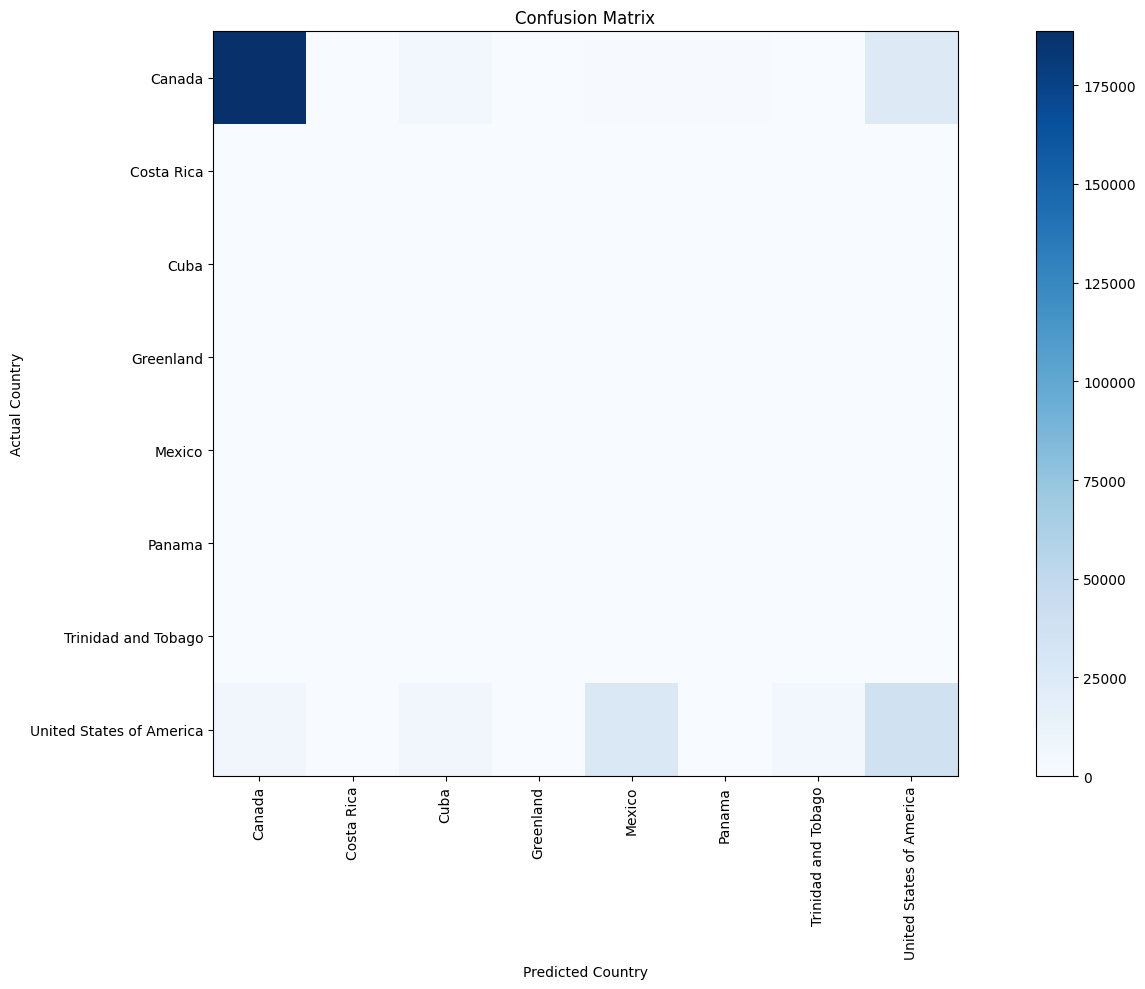

In [16]:
# Evaluate accuracy and show confusion matrix
# Remove any rows in y_test or y_pred where y_test is NaN, to avoid comparison errors
mask = ~y_test.isna()
y_test_clean = y_test[mask]
y_pred_clean = pd.Series(y_pred, index=y_test.index)[mask]

# Use all unique classes in y_test for confusion matrix labels
labels = np.unique(list(y_test_clean) + list(y_pred_clean))
acc = accuracy_score(y_test_clean, y_pred_clean)
print(f"Accuracy: {acc:.2f}")
cm = confusion_matrix(y_test_clean, y_pred_clean, labels=labels)
plt.figure(figsize=(16,10))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Country')
plt.ylabel('Actual Country')
plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=90)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)
plt.colorbar()
plt.tight_layout()
plt.show()

## 6. Evaluate Model Performance
Assess accuracy and display a confusion matrix for the region predictions.

Accuracy: 0.74


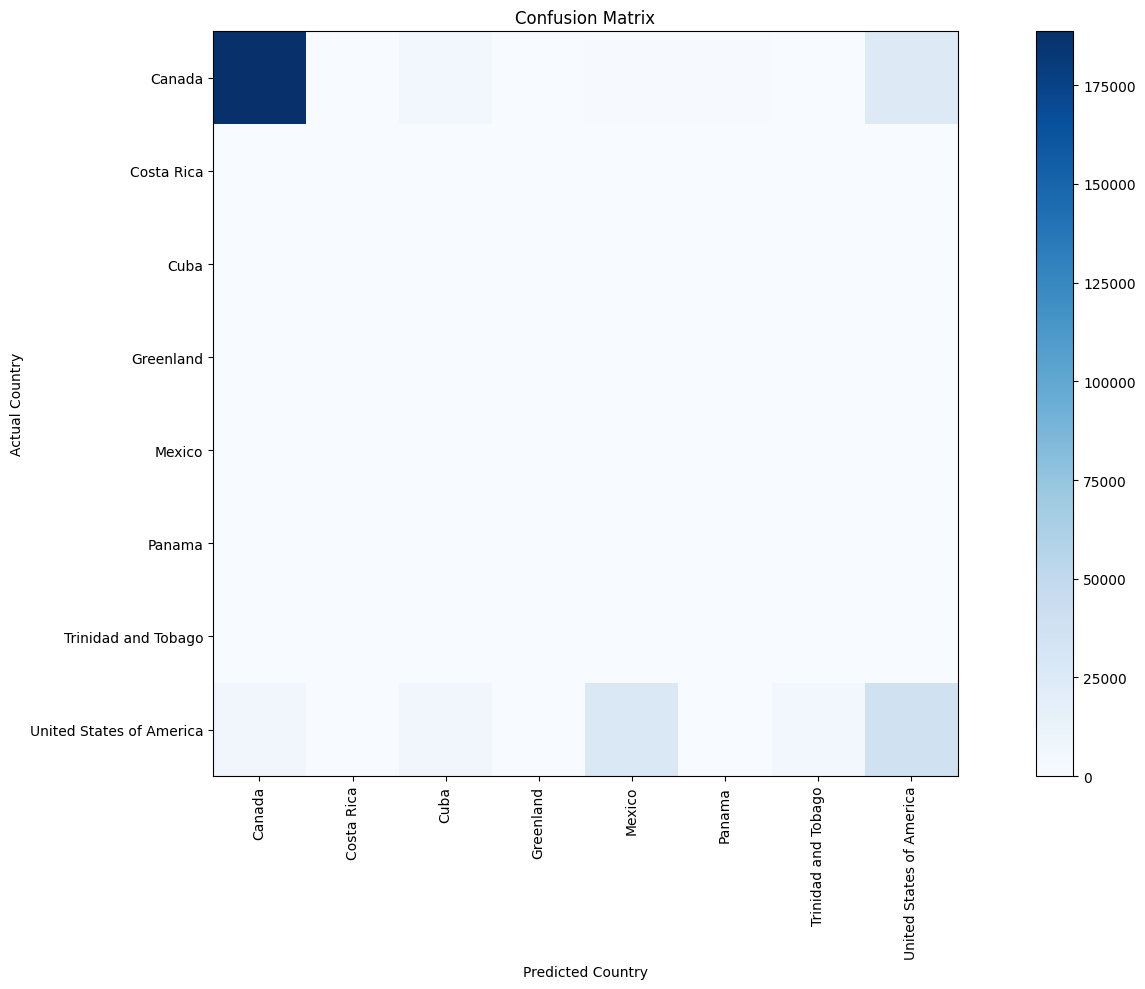

In [17]:
# Evaluate accuracy and show confusion matrix for country prediction
from sklearn.utils.multiclass import unique_labels
mask = ~y_test.isna()
y_test_clean = y_test[mask]
y_pred_clean = pd.Series(y_pred, index=y_test.index)[mask]

acc = accuracy_score(y_test_clean, y_pred_clean)
print(f"Accuracy: {acc:.2f}")
labels = unique_labels(y_test_clean, y_pred_clean)
cm = confusion_matrix(y_test_clean, y_pred_clean, labels=labels)
plt.figure(figsize=(16,10))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Country')
plt.ylabel('Actual Country')
plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=90)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)
plt.colorbar()
plt.tight_layout()
plt.show()

## 7. Visualize Predictions on a Folium Map
Plot a sample of predicted vs. actual regions on an interactive folium map for North America.

In [19]:
# Visualize a sample of predictions on a folium map (country prediction)
# Ensure the actual and predicted country are correct for each point
sample = X_test.copy()
sample['actual_country'] = y_test
sample['predicted_country'] = y_pred
sample = sample[~sample['actual_country'].isna()]
sample = sample.sample(n=min(200, len(sample)), random_state=42)

m = folium.Map(location=[40, -100], zoom_start=3)  # Center of North America
for _, row in sample.iterrows():
    color = 'green' if row['actual_country'] == row['predicted_country'] else 'red'
    # Get lat/lon from original df using index
    idx = row.name
    lat = df.loc[idx, 'lat_dd'] if idx in df.index else None
    lon = df.loc[idx, 'lon_dd'] if idx in df.index else None
    if pd.notnull(lat) and pd.notnull(lon):
        folium.CircleMarker(
            location=[lat, lon],
            radius=4,
            color=color,
            fill=True,
            fill_color=color,
            popup=f"Lat: {lat:.2f}, Lon: {lon:.2f}<br>Actual: {row['actual_country']}<br>Predicted: {row['predicted_country']}"
        ).add_to(m)
m.save('north_america_predicted_vs_actual_map.html')
print('Map saved to north_america_predicted_vs_actual_map.html')

Map saved to north_america_predicted_vs_actual_map.html


## 8. Visualize Main Variation in Bird Features Using PCA
Principal Component Analysis (PCA) helps us understand the main axes of variation in the selected bird features. We'll project the data onto the first two principal components and color points by country.

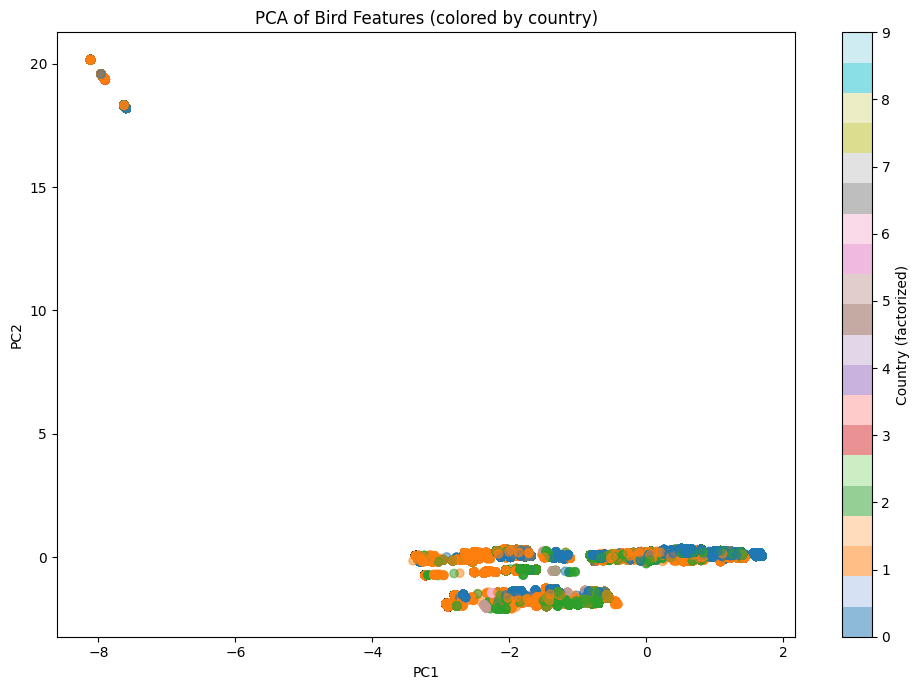

In [20]:
# --- PCA Visualization of Bird Features ---
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Use the same selected features as for prediction
pca_features = ['event_month', 'season', 'age_code', 'extra_info_code']
pca_features = [f for f in pca_features if f in df.columns]
X_pca = df[pca_features].copy()

# One-hot encode 'season' if present
if 'season' in X_pca.columns:
    X_pca = pd.get_dummies(X_pca, columns=['season'])
# Fill missing values for numeric columns
for col in X_pca.select_dtypes(include=[np.number]).columns:
    X_pca[col] = X_pca[col].fillna(X_pca[col].median())
# Encode categorical columns (except one-hot)
from sklearn.preprocessing import LabelEncoder
for col in X_pca.select_dtypes(include=['object', 'category']).columns:
    X_pca[col] = LabelEncoder().fit_transform(X_pca[col].astype(str))

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# Run PCA
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_scaled)

# Prepare color labels (country)
country_labels = df['country_from_geom'].astype(str).values

# Plot PCA
plt.figure(figsize=(10,7))
scatter = plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=pd.factorize(country_labels)[0], cmap='tab20', alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Bird Features (colored by country)')
plt.colorbar(scatter, label='Country (factorized)')
plt.tight_layout()
plt.show()